## 1. 라이브러리 임포트 및 데이터 로드

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import KFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error,
)

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor


sns.set(style="whitegrid", font="Malgun Gothic")  # 윈도우 한글 폰트
plt.rcParams["axes.unicode_minus"] = False        # 마이너스 깨짐 방지

# notebooks/ 기준으로 상위 폴더의 data 디렉터리 사용
BASE_DIR = Path().resolve().parent / "data"

train_path = BASE_DIR / "월세_train(24.01~25.08).csv"
test_path  = BASE_DIR / "월세_test(25.09~25.10).csv"

train = pd.read_csv(train_path, encoding="utf-8-sig")
test  = pd.read_csv(test_path,  encoding="utf-8-sig")

print("train:", train.shape)
print("test :", test.shape)
train.head()


train: (618550, 17)
test : (74617, 17)


,자치구명,법정동명,층,연월,임대면적,보증금(만원),임대료(만원),건축년도,건물용도,소비자물가,무담보콜금리,KORIBOR,CD,기업대출,전세자금대출,변동형주택담보대출,기준금리
0,마포구,노고산동,5.0,2024-12,31.12,8000,50,1998.0,오피스텔,1.9,3.055,3.31,3.35,4.62,4.34,4.32,3.00
1,관악구,신림동,0.0,2024-10,50.00,27000,15,2024.0,단독다가구,1.3,3.321,3.43,3.43,4.71,4.26,4.14,3.50
2,중랑구,면목동,0.0,2024-10,50.00,3000,90,2018.0,단독다가구,1.3,3.321,3.43,3.43,4.71,4.26,4.14,3.50
3,종로구,명륜3가,2.0,2024-09,20.96,500,76,1996.0,연립다세대,1.6,3.529,3.49,3.52,4.77,4.05,4.08,3.50
4,강서구,공항동,0.0,2024-11,46.98,1000,60,2002.0,단독다가구,1.5,3.245,3.40,3.42,4.76,4.43,4.25,3.25


## 전처리

In [2]:
df_train = train.copy()
df_test  = test.copy()

# 1) 계약일 → datetime / 연,월,연월
for df in [df_train, df_test]:
    if "계약일" in df.columns:
        df["계약일"] = pd.to_datetime(df["계약일"].astype(str), format="%Y%m%d", errors="coerce")
        df["계약연도"] = df["계약일"].dt.year
        df["계약월"] = df["계약일"].dt.month
        df["연월"] = df["계약일"].dt.to_period("M").astype(str)

# 2) 숫자형으로 쓸 컬럼들 변환
num_cols_to_cast = ["층", "임대면적", "보증금(만원)", "임대료(만원)", "건축년도"]
for df in [df_train, df_test]:
    for col in num_cols_to_cast:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

# 3) 건물 연식 (계약연도 - 건축년도)
for df in [df_train, df_test]:
    if {"건축년도", "계약연도"}.issubset(df.columns):
        df["건물연식"] = df["계약연도"] - df["건축년도"]

df_train.head()


,자치구명,법정동명,층,연월,임대면적,보증금(만원),임대료(만원),건축년도,건물용도,소비자물가,무담보콜금리,KORIBOR,CD,기업대출,전세자금대출,변동형주택담보대출,기준금리
0,마포구,노고산동,5.0,2024-12,31.12,8000,50,1998.0,오피스텔,1.9,3.055,3.31,3.35,4.62,4.34,4.32,3.00
1,관악구,신림동,0.0,2024-10,50.00,27000,15,2024.0,단독다가구,1.3,3.321,3.43,3.43,4.71,4.26,4.14,3.50
2,중랑구,면목동,0.0,2024-10,50.00,3000,90,2018.0,단독다가구,1.3,3.321,3.43,3.43,4.71,4.26,4.14,3.50
3,종로구,명륜3가,2.0,2024-09,20.96,500,76,1996.0,연립다세대,1.6,3.529,3.49,3.52,4.77,4.05,4.08,3.50
4,강서구,공항동,0.0,2024-11,46.98,1000,60,2002.0,단독다가구,1.5,3.245,3.40,3.42,4.76,4.43,4.25,3.25


## 환산보증금_평당가 타깃 생성
> 환산보증금 = 보증금 + (월세*12) / ((기준금리+2)/100)

In [3]:
TARGET = "환산보증금_평당가"
TARGET_LOG = "log_" + TARGET 

for df in [df_train, df_test]:
    # 안전한 최소 이자율 (0 이하 방지)
    df["적용이자율"] = (df["기준금리"] + 2.0) / 100.0
    df.loc[df["적용이자율"] <= 0, "적용이자율"] = np.nan

    # 환산보증금: 보증금 + 월세를 전세로 환산
    df["환산보증금(만원)"] = df["보증금(만원)"] + (df["임대료(만원)"] * 12) / df["적용이자율"]

    # 평수 (임대면적이 ㎡라면 3.3으로 나눔)
    df["전용평수"] = df["임대면적"] / 3.3

    # 평당 환산보증금 (타깃)
    df[TARGET] = df["환산보증금(만원)"] / df["전용평수"]

    df[TARGET_LOG] = np.log1p(df[TARGET])

    # 연월에서 연도/월 분리
    df["계약연도"] = df["연월"].str.slice(0, 4).astype(int)
    df["계약월"]   = df["연월"].str.slice(5, 7).astype(int)

    # 계약월은 범주형으로 취급
    df["계약월"] = df["계약월"].astype("category")

df_train[[ "보증금(만원)", "임대료(만원)", "기준금리", "적용이자율", "환산보증금(만원)", "전용평수", TARGET]].head()


,보증금(만원),임대료(만원),기준금리,적용이자율,환산보증금(만원),전용평수,환산보증금_평당가
0,8000,50,3.00,0.0500,20000.000000,9.430303,2120.822622
1,27000,15,3.50,0.0550,30272.727273,15.151515,1998.000000
2,3000,90,3.50,0.0550,22636.363636,15.151515,1494.000000
3,500,76,3.50,0.0550,17081.818182,6.351515,2689.408397
4,1000,60,3.25,0.0525,14714.285714,14.236364,1033.570516


In [4]:
print("=== train.info ===")
df_train.info()

=== train.info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 618550 entries, 0 to 618549
Data columns (total 24 columns):
 #   Column         Non-Null Count   Dtype   
---  ------         --------------   -----   
 0   자치구명           618550 non-null  object  
 1   법정동명           618550 non-null  object  
 2   층              618550 non-null  float64 
 3   연월             618550 non-null  object  
 4   임대면적           618550 non-null  float64 
 5   보증금(만원)        618550 non-null  int64   
 6   임대료(만원)        618550 non-null  int64   
 7   건축년도           618550 non-null  float64 
 8   건물용도           618550 non-null  object  
 9   소비자물가          618550 non-null  float64 
 10  무담보콜금리         618550 non-null  float64 
 11  KORIBOR        618550 non-null  float64 
 12  CD             618550 non-null  float64 
 13  기업대출           618550 non-null  float64 
 14  전세자금대출         618550 non-null  float64 
 15  변동형주택담보대출      618550 non-null  float64 
 16  기준금리           618550 non-null  float

In [5]:
print("\n=== 결측비율 (train) ===")
df_train.isnull().sum().sort_values(ascending=False).head(20)


=== 결측비율 (train) ===


자치구명         0
법정동명         0
층            0
연월           0
임대면적         0
보증금(만원)      0
임대료(만원)      0
건축년도         0
건물용도         0
소비자물가        0
무담보콜금리       0
KORIBOR      0
CD           0
기업대출         0
전세자금대출       0
변동형주택담보대출    0
기준금리         0
적용이자율        0
환산보증금(만원)    0
전용평수         0
dtype: int64

## EDA

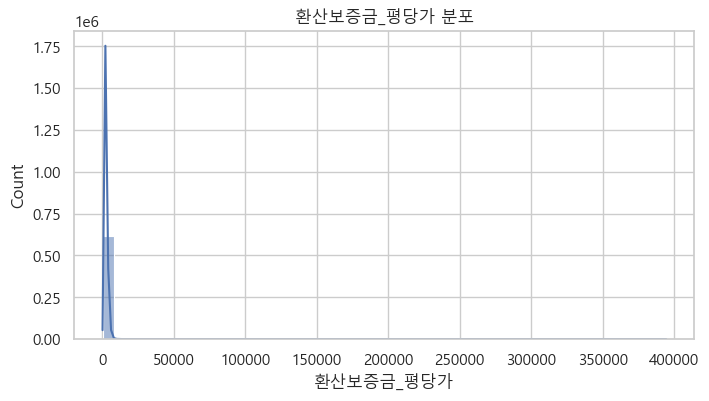

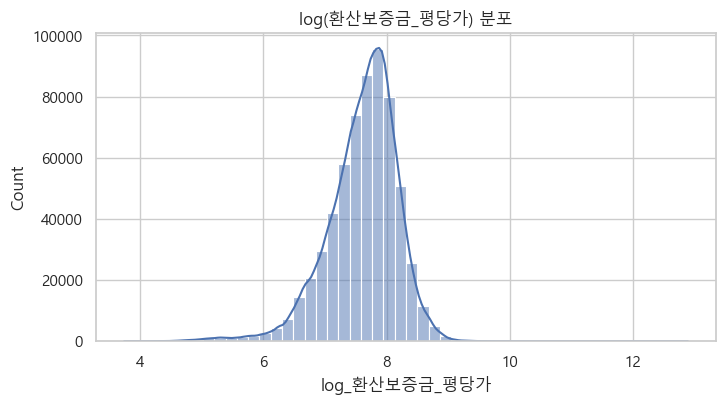

In [6]:
# 타깃 분포
plt.figure(figsize=(8, 4))
sns.histplot(df_train[TARGET].dropna(), bins=50, kde=True)
plt.title("환산보증금_평당가 분포")
plt.show()

# 로그 스케일 분포 (꼬리 완화용)
df_train["log_" + TARGET] = np.log1p(df_train[TARGET])

plt.figure(figsize=(8, 4))
sns.histplot(df_train["log_" + TARGET].dropna(), bins=50, kde=True)
plt.title("log(환산보증금_평당가) 분포")
plt.show()


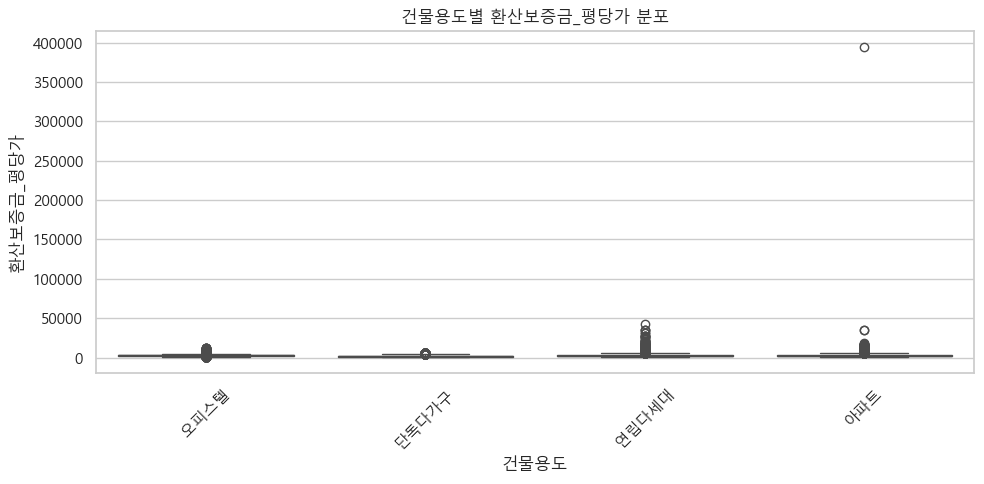

In [7]:
# 건물용도별 평당가
if "건물용도" in df_train.columns:
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=df_train, x="건물용도", y=TARGET)
    plt.xticks(rotation=45)
    plt.title("건물용도별 환산보증금_평당가 분포")
    plt.tight_layout()
    plt.show()

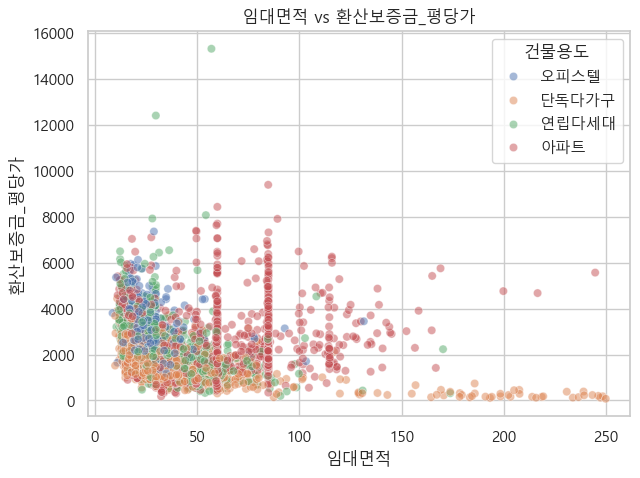

In [8]:
# 임대면적 vs 평당가 (면적이 큰 집일수록 평당가 하락하는지 등)
plt.figure(figsize=(7, 5))
sample = df_train.sample(min(len(df_train), 4000), random_state=42)
sns.scatterplot(data=sample, x="임대면적", y=TARGET, hue="건물용도", alpha=0.5)
plt.title("임대면적 vs 환산보증금_평당가")
plt.show()


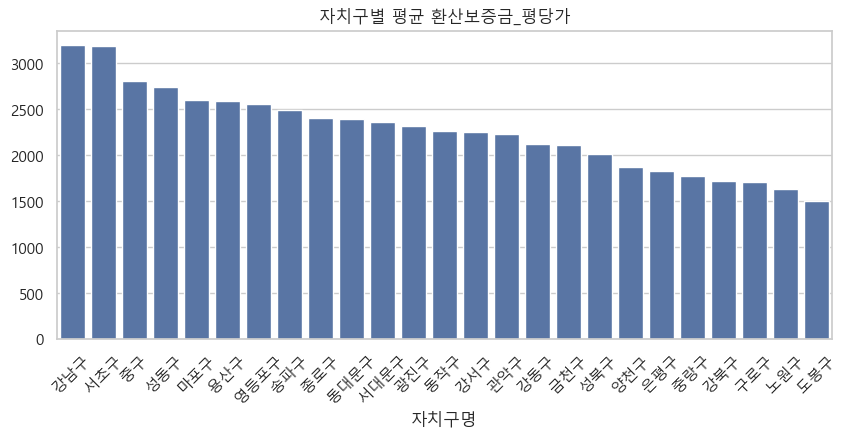

In [9]:
# 자치구별 평균 평당가 (지역 프리미엄)
if {"자치구명", TARGET}.issubset(df_train.columns):
    gu_mean = df_train.groupby("자치구명")[TARGET].mean().sort_values(ascending=False)
    plt.figure(figsize=(10, 4))
    sns.barplot(x=gu_mean.index.astype(str), y=gu_mean.values)
    plt.xticks(rotation=45)
    plt.title("자치구별 평균 환산보증금_평당가")
    plt.show()


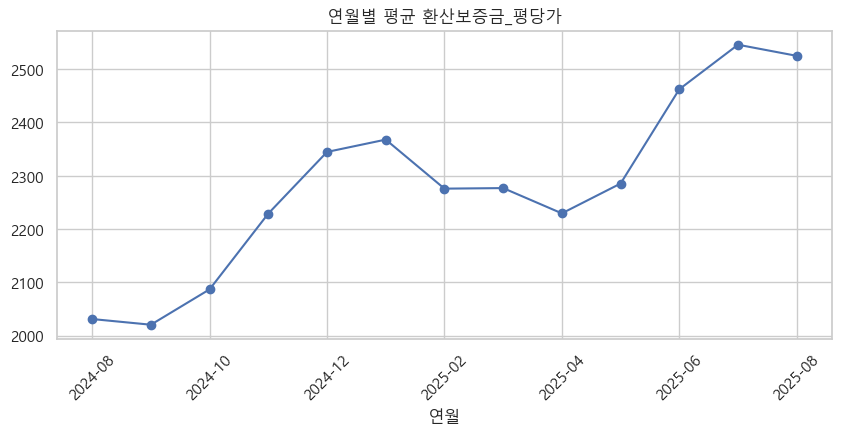

In [10]:
# 시간(연월)에 따른 시세 흐름
if {"연월", TARGET}.issubset(df_train.columns):
    month_mean = df_train.groupby("연월")[TARGET].mean()
    plt.figure(figsize=(10, 4))
    month_mean.plot(marker="o")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.title("연월별 평균 환산보증금_평당가")
    plt.show()


In [11]:
num_cols = df_train.select_dtypes(include=[np.number]).columns.tolist()
corr = df_train[num_cols].corr()

# 타깃과의 상관계수
target_corr = corr[TARGET].sort_values(ascending=False)
target_corr

환산보증금_평당가        1.000000
log_환산보증금_평당가    0.840837
환산보증금(만원)        0.525071
임대료(만원)          0.485398
건축년도             0.415858
층                0.335592
보증금(만원)          0.311874
계약연도             0.064304
소비자물가            0.039183
변동형주택담보대출       -0.018680
전세자금대출          -0.043340
기업대출            -0.081347
KORIBOR         -0.085550
CD              -0.085954
무담보콜금리          -0.094741
기준금리            -0.096646
적용이자율           -0.096646
전용평수            -0.136347
임대면적            -0.136347
Name: 환산보증금_평당가, dtype: float64

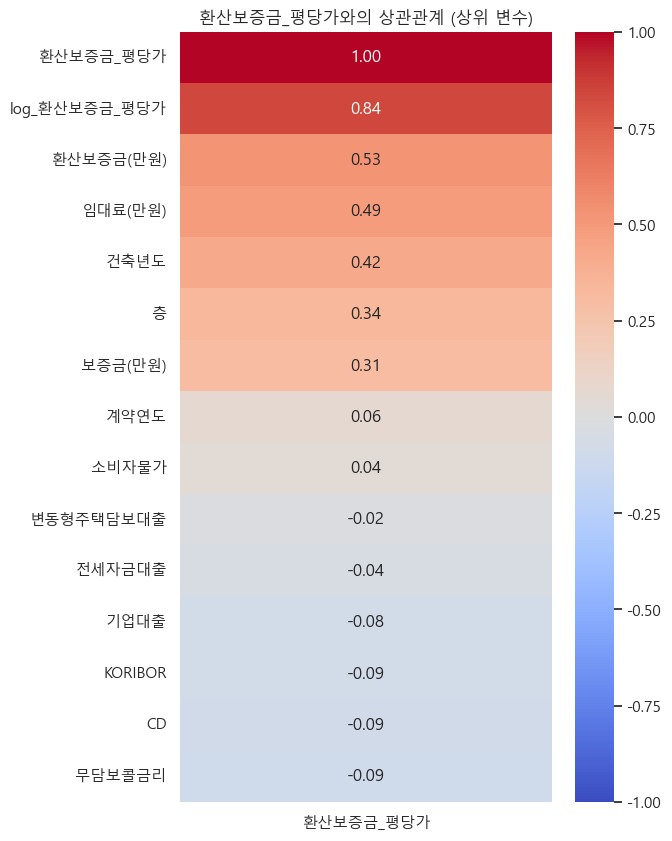

In [12]:
# 타깃과 상관 높은 상위 변수 히트맵
top_n = 15
top_features = target_corr.index[:top_n]

plt.figure(figsize=(6, 10))
sns.heatmap(
    corr.loc[top_features, [TARGET]],
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)
plt.title("환산보증금_평당가와의 상관관계 (상위 변수)")
plt.show()


## Features

In [13]:
from sklearn.model_selection import KFold
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import LabelEncoder

TARGET = "환산보증금_평당가"
TARGET_LOG = "log_" + TARGET

# 1) 모델링에 쓸 행만 남기기
df_train_ml = df_train.dropna(subset=[TARGET_LOG]).copy()
df_train_ml = df_train_ml.sort_values("연월").reset_index(drop=True)
df_test_ml  = df_test.copy()

# ===================================
# 2) K-Fold Target Encoding (Data Leakage 방지)
# ===================================

# def kfold_target_encoding(X, y, X_test, col, n_splits=5, smoothing=10):
#     """TimeSeriesSplit + 베이즈식 스무딩 Target Encoding"""
#     tscv = TimeSeriesSplit(n_splits=n_splits)
#     train_te = np.zeros(len(X))
#     global_mean = y.mean()

#     # Train: 과거 → 미래 순서로 OOF 인코딩
#     for train_idx, val_idx in tscv.split(X):
#         temp_train = pd.DataFrame({
#             "category": X.iloc[train_idx][col].values,
#             "target": y.iloc[train_idx].values,
#         })
#         stats = temp_train.groupby("category")["target"].agg(["mean", "count"])
#         smooth = (stats["mean"] * stats["count"] + global_mean * smoothing) / (
#             stats["count"] + smoothing
#         )
#         mapping = smooth

#         vals = X.iloc[val_idx][col]
#         train_te[val_idx] = vals.map(mapping).fillna(global_mean)

#     # Test: 전체 train 기준으로 스무딩 평균
#     temp_full = pd.DataFrame({
#         "category": X[col].values,
#         "target": y.values,
#     })
#     stats_full = temp_full.groupby("category")["target"].agg(["mean", "count"])
#     smooth_full = (stats_full["mean"] * stats_full["count"] + global_mean * smoothing) / (
#         stats_full["count"] + smoothing
#     )
#     global_mapping = smooth_full

#     test_te = X_test[col].map(global_mapping).fillna(global_mean)

#     return train_te, test_te


# # 적용할 Target Encoding 컬럼들
# te_cols = ["자치구명", "법정동명"]

# for col in te_cols:
#     col_te = col + "_TE"
#     train_te, test_te = kfold_target_encoding(
#         df_train_ml[[col]], df_train_ml[TARGET_LOG], 
#         df_test_ml[[col]], col
#     )
#     df_train_ml[col_te] = train_te
#     df_test_ml[col_te] = test_te

# ===================================
# 2) Label Encoding으로 변경
# ===================================



# 2-1) 복합 카테고리 생성
df_train_ml["자치구_건물용도"] = df_train_ml["자치구명"] + "_" + df_train_ml["건물용도"]
df_test_ml["자치구_건물용도"] = df_test_ml["자치구명"] + "_" + df_test_ml["건물용도"]

# 2-2) 각 범주형 컬럼별로 LabelEncoder 적용 (train+test 전체 기준)
cat_cols_for_le = ["자치구명", "법정동명", "자치구_건물용도"]

for col in cat_cols_for_le:
    le = LabelEncoder()
    
    # train과 test를 합쳐서 모든 카테고리로 학습
    all_vals = pd.concat([df_train_ml[col], df_test_ml[col]]).astype(str)
    le.fit(all_vals)
    
    df_train_ml[col + "_LE"] = le.transform(df_train_ml[col].astype(str))
    df_test_ml[col + "_LE"] = le.transform(df_test_ml[col].astype(str))



# ===================================
# 3) 복합 Target Encoding (지역 x 건물용도)
# ===================================

# # 복합 카테고리
# df_train_ml["자치구_건물용도"] = df_train_ml["자치구명"] + "_" + df_train_ml["건물용도"]
# df_test_ml["자치구_건물용도"] = df_test_ml["자치구명"] + "_" + df_test_ml["건물용도"]

# # 복합 TE 적용
# col = "자치구_건물용도"
# col_te = col + "_TE"
# train_te, test_te = kfold_target_encoding(
#     df_train_ml[[col]], df_train_ml[TARGET_LOG],
#     df_test_ml[[col]], col
# )
# df_train_ml[col_te] = train_te
# df_test_ml[col_te] = test_te

# ===================================
# 4) 계약월을 숫자형으로 변환 (category → int)
# ===================================

df_train_ml["계약월"] = df_train_ml["계약월"].astype(int)
df_test_ml["계약월"] = df_test_ml["계약월"].astype(int)

# ===================================
# 5) 최종 피처 선택
# ===================================

candidate_features = [
    # Target Encoding 피처들
    "자치구명_LE", "법정동명_LE",
    "자치구_건물용도_LE", 
    
    # 건물 특성
    "건물연식",
    "건물용도",
    
    # 면적
    "임대면적",
    
    # 금리
    "기준금리", "CD", "KORIBOR", "기업대출", "무담보콜금리",
    "전세자금대출", "변동형주택담보대출",
    
    # 거시경제
    "소비자물가",
    
    # 시간
    "계약연도", 
    "계약월"  # 숫자형으로 변환됨
]

# 실제 존재하는 컬럼만 필터링
candidate_features = [c for c in candidate_features if c in df_train_ml.columns]

# 6) 피처/타깃 분리
X_train_ml = df_train_ml[candidate_features]
y_train_ml = df_train_ml[TARGET_LOG]

X_test_ml = df_test_ml[candidate_features]
y_test_ml = df_test_ml[TARGET_LOG]  # 평가용

print(f"✅ Feature Engineering 완료!")
print(f"   - Train: {X_train_ml.shape}")
print(f"   - Test:  {X_test_ml.shape}")
print(f"   - 총 피처 수: {len(candidate_features)}개")
print(f"\n사용된 피처 목록:")
for i, feat in enumerate(candidate_features, 1):
    print(f"   {i:2d}. {feat}")


✅ Feature Engineering 완료!
   - Train: (618550, 15)
   - Test:  (74617, 15)
   - 총 피처 수: 15개

사용된 피처 목록:
    1. 자치구명_LE
    2. 법정동명_LE
    3. 자치구_건물용도_LE
    4. 건물용도
    5. 임대면적
    6. 기준금리
    7. CD
    8. KORIBOR
    9. 기업대출
   10. 무담보콜금리
   11. 전세자금대출
   12. 변동형주택담보대출
   13. 소비자물가
   14. 계약연도
   15. 계약월


## 전처리 파이프라인 및 모델 정의

In [14]:
# ===================================
# 전처리 파이프라인 및 모델 정의
# ===================================

# 숫자 / 범주 피처 분리 (train 기준)
numeric_features = X_train_ml.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = [c for c in X_train_ml.columns if c not in numeric_features]

print(f"📊 피처 타입:")
print(f"   - 수치형: {len(numeric_features)}개 - {numeric_features}")
print(f"   - 범주형: {len(categorical_features)}개 - {categorical_features}")

# 전처리 파이프라인 (건물용도만 OneHot)
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
    ]
)

# ===================================
# 모델 정의 (하이퍼파라미터 최적화 + early_stopping)
# ===================================

models = {
    "XGBoost": XGBRegressor(
        n_estimators=3000,
        learning_rate=0.03,
        max_depth=12,
        min_child_weight=1,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.05,
        reg_lambda=1.5,
        gamma=0.05,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1,
    ),
    
    "LightGBM": LGBMRegressor(
        n_estimators=3000,
        learning_rate=0.03,
        max_depth=-1,
        num_leaves=255,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.05,
        reg_lambda=1.5,
        min_split_gain=0.005,
        random_state=42,
        n_jobs=-1,
        verbose=-1,
    )
}

print(f"\n✅ 모델 정의 완료:")
for name in models.keys():
    print(f"   - {name}")

📊 피처 타입:
   - 수치형: 14개 - ['자치구명_LE', '법정동명_LE', '자치구_건물용도_LE', '임대면적', '기준금리', 'CD', 'KORIBOR', '기업대출', '무담보콜금리', '전세자금대출', '변동형주택담보대출', '소비자물가', '계약연도', '계약월']
   - 범주형: 1개 - ['건물용도']

✅ 모델 정의 완료:
   - XGBoost
   - LightGBM


## Train / Val 분할

In [15]:
# ===================================
# Train / Val 분할 (날짜 기준 - 시계열 고려)
# ===================================

# 시계열 데이터는 랜덤 split이 아닌 시간 순서 기반 split 필요
# Train: 2024-08 ~ 2025-05 (초기 10개월)
# Val:   2025-06 ~ 2025-08 (중간 3개월)

# 연월 정보 확인
print("📅 연월 분포:")
print(df_train_ml["연월"].value_counts().sort_index())

# 날짜 기준 정렬
df_train_ml_sorted = df_train_ml.sort_values("연월").reset_index(drop=True)

# 날짜 기준 분할 (명확한 기준)
train_mask = df_train_ml_sorted["연월"] < "2025-06"
val_mask = (df_train_ml_sorted["연월"] >= "2025-06") & (df_train_ml_sorted["연월"] < "2025-09")

# Train / Val 분할
train_data = df_train_ml_sorted[train_mask]
val_data = df_train_ml_sorted[val_mask]

X_tr = train_data[candidate_features]
y_tr = train_data[TARGET_LOG]

X_val = val_data[candidate_features]
y_val = val_data[TARGET_LOG]

print(f"\n✅ 시계열 기반 Train/Val Split 완료:")
print(f"   - Train: {len(X_tr):,}개 ({len(X_tr)/len(df_train_ml_sorted)*100:.1f}%)")
print(f"   - Val:   {len(X_val):,}개 ({len(X_val)/len(df_train_ml_sorted)*100:.1f}%)")

# 날짜 범위 확인
print(f"\n   - Train 기간: {train_data['연월'].min()} ~ {train_data['연월'].max()}")
print(f"   - Val 기간:   {val_data['연월'].min()} ~ {val_data['연월'].max()}")

# 평가 지표 함수
def eval_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = mse ** 0.5
    mape = mean_absolute_percentage_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, mape, r2

📅 연월 분포:
연월
2024-08    24728
2024-09    20758
2024-10    25547
2024-11    28395
2024-12    42036
2025-01    56962
2025-02    69745
2025-03    57757
2025-04    55247
2025-05    58948
2025-06    59621
2025-07    59691
2025-08    59115
Name: count, dtype: int64

✅ 시계열 기반 Train/Val Split 완료:
   - Train: 440,123개 (71.2%)
   - Val:   178,427개 (28.8%)

   - Train 기간: 2024-08 ~ 2025-05
   - Val 기간:   2025-06 ~ 2025-08


## 학습

In [16]:
import warnings
warnings.filterwarnings("ignore")

results = []

# 전처리 먼저 적용 (한 번만)
print("🔧 데이터 전처리 중...")
X_tr_transformed = preprocess.fit_transform(X_tr)
X_val_transformed = preprocess.transform(X_val)
X_test_transformed = preprocess.transform(X_test_ml)

print(f"   - Train shape: {X_tr_transformed.shape}")
print(f"   - Val shape:   {X_val_transformed.shape}")
print(f"   - Test shape:  {X_test_transformed.shape}")

for name, reg in models.items():
    print(f"\n{'='*60}")
    print(f"🚀 학습 중: {name}")
    print(f"{'='*60}")

    # 1) 학습 (TARGET_LOG 기준, early_stopping 사용)
    if name == "XGBoost":
        reg.fit(
            X_tr_transformed, y_tr,
            eval_set=[(X_tr_transformed, y_tr), (X_val_transformed, y_val)],
            verbose=200,
        )
    else:  # LightGBM
        reg.fit(
            X_tr_transformed, y_tr,
            eval_set=[(X_tr_transformed, y_tr), (X_val_transformed, y_val)],
            eval_metric="rmse",
        )

    # 2) 로그 스케일 예측값
    pred_tr_log = reg.predict(X_tr_transformed)
    pred_val_log = reg.predict(X_val_transformed)
    pred_test_log = reg.predict(X_test_transformed)

    # 3) 로그 역변환 (log1p 기준)
    y_tr_real = np.expm1(y_tr)
    y_val_real = np.expm1(y_val)
    y_test_real = np.expm1(y_test_ml)

    pred_tr_real = np.expm1(pred_tr_log)
    pred_val_real = np.expm1(pred_val_log)
    pred_test_real = np.expm1(pred_test_log)

    # 4) 원 스케일에서 지표 계산
    mae_tr, rmse_tr, mape_tr, r2_tr = eval_metrics(y_tr_real, pred_tr_real)
    mae_val, rmse_val, mape_val, r2_val = eval_metrics(y_val_real, pred_val_real)
    mae_te, rmse_te, mape_te, r2_te = eval_metrics(y_test_real, pred_test_real)

    # 5) 결과 저장
    results.append({
        "model": name,
        "R2_train": r2_tr,
        "MAE_train": mae_tr,
        "RMSE_train": rmse_tr,
        "MAPE_train": mape_tr,
        "R2_val": r2_val,
        "MAE_val": mae_val,
        "RMSE_val": rmse_val,
        "MAPE_val": mape_val,
        "R2_test": r2_te,
        "MAE_test": mae_te,
        "RMSE_test": rmse_te,
        "MAPE_test": mape_te,
    })

    # 6) 결과 출력
    print(f"\n📈 [{name}] 성능 지표 (원 스케일):")
    print(f"   [Train] R²: {r2_tr:.4f} | MAE: {mae_tr:.3f} | RMSE: {rmse_tr:.3f} | MAPE: {mape_tr*100:.2f}%")
    print(f"   [Val]   R²: {r2_val:.4f} | MAE: {mae_val:.3f} | RMSE: {rmse_val:.3f} | MAPE: {mape_val*100:.2f}%")
    print(f"   [Test]  R²: {r2_te:.4f} | MAE: {mae_te:.3f} | RMSE: {rmse_te:.3f} | MAPE: {mape_te*100:.2f}%")


print(f"\n{'='*60}")
print(f"📊 전체 모델 비교 (Test R² 기준)")
print(f"{'='*60}")

results_df = pd.DataFrame(results)
results_df = results_df.sort_values("R2_test", ascending=False)
display(results_df)

# 최고 성능 모델
best_model = results_df.iloc[0]["model"]
best_r2 = results_df.iloc[0]["R2_test"]

print(f"\n🏆 최고 성능 모델: {best_model} (Test R² = {best_r2:.4f})")

🔧 데이터 전처리 중...
   - Train shape: (440123, 18)
   - Val shape:   (178427, 18)
   - Test shape:  (74617, 18)

🚀 학습 중: XGBoost
[0]	validation_0-rmse:0.55533	validation_1-rmse:0.56563
[200]	validation_0-rmse:0.26666	validation_1-rmse:0.32167
[400]	validation_0-rmse:0.24691	validation_1-rmse:0.31716
[600]	validation_0-rmse:0.23758	validation_1-rmse:0.31653
[800]	validation_0-rmse:0.23223	validation_1-rmse:0.31653
[1000]	validation_0-rmse:0.22858	validation_1-rmse:0.31669
[1200]	validation_0-rmse:0.22574	validation_1-rmse:0.31676
[1400]	validation_0-rmse:0.22354	validation_1-rmse:0.31699
[1600]	validation_0-rmse:0.22185	validation_1-rmse:0.31721
[1800]	validation_0-rmse:0.22023	validation_1-rmse:0.31735
[2000]	validation_0-rmse:0.21920	validation_1-rmse:0.31742
[2200]	validation_0-rmse:0.21798	validation_1-rmse:0.31750
[2400]	validation_0-rmse:0.21712	validation_1-rmse:0.31759
[2600]	validation_0-rmse:0.21622	validation_1-rmse:0.31773
[2800]	validation_0-rmse:0.21513	validation_1-rmse:0.3178

,model,R2_train,MAE_train,RMSE_train,MAPE_train,R2_val,MAE_val,RMSE_val,MAPE_val,R2_test,MAE_test,RMSE_test,MAPE_test
0,XGBoost,0.647256,312.366343,763.621819,0.157709,0.634572,506.678456,784.351888,0.235175,0.634096,513.144319,784.080875,0.240950
1,LightGBM,0.591399,371.654721,821.860777,0.193571,0.626887,513.251572,792.556120,0.234497,0.626844,519.090672,791.812718,0.239704



🏆 최고 성능 모델: XGBoost (Test R² = 0.6341)


## Stacking Ensemble (최종 성능 향상)

## Shap

In [17]:
import shap

# ===================================
# SHAP 분석: 피처 중요도 및 해석
# ===================================

print("🔍 SHAP 분석 시작...")
print(f"   - 분석 대상: {best_model}")

# 1) 이미 학습된 모델 사용 (재학습 불필요!)
best_reg = models[best_model]

print(f"   - 학습된 모델 로드 완료")

# 2) SHAP 분석용 샘플 추출 (속도 고려)
sample_size = min(2000, len(X_train_ml))
X_sample = X_train_ml.sample(sample_size, random_state=42)

print(f"   - 샘플 추출 완료: {sample_size}개")

# 3) 전처리 적용 (이미 fit된 preprocess 사용)
X_sample_trans = preprocess.transform(X_sample)

# 피처 이름 가져오기
try:
    feature_names = preprocess.get_feature_names_out()
except AttributeError:
    # sklearn 구버전 대응
    feature_names = []
    for name, trans, cols in preprocess.transformers_:
        if name == "num":
            feature_names.extend([f"num__{c}" for c in cols])
        elif name == "cat":
            if hasattr(trans, 'get_feature_names_out'):
                feature_names.extend(trans.get_feature_names_out(cols))
            else:
                feature_names.extend([f"cat__{c}" for c in cols])

print(f"   - 전처리 후 피처 수: {len(feature_names)}개")

# 4) SHAP TreeExplainer 생성 (이미 학습된 모델 사용)
print(f"   - TreeExplainer 생성 중...")
explainer = shap.TreeExplainer(best_reg)

# 5) SHAP 값 계산
print(f"   - SHAP 값 계산 중...")
shap_values = explainer.shap_values(X_sample_trans)

print("\n✅ SHAP 분석 완료!")
print(f"   - SHAP 값 shape: {shap_values.shape}")
print(f"   - 사용된 모델: 이미 학습된 {best_model}")


🔍 SHAP 분석 시작...
   - 분석 대상: XGBoost
   - 학습된 모델 로드 완료
   - 샘플 추출 완료: 2000개
   - 전처리 후 피처 수: 18개
   - TreeExplainer 생성 중...
   - SHAP 값 계산 중...

✅ SHAP 분석 완료!
   - SHAP 값 shape: (2000, 18)
   - 사용된 모델: 이미 학습된 XGBoost


### SHAP Summary Plot - 피처 중요도

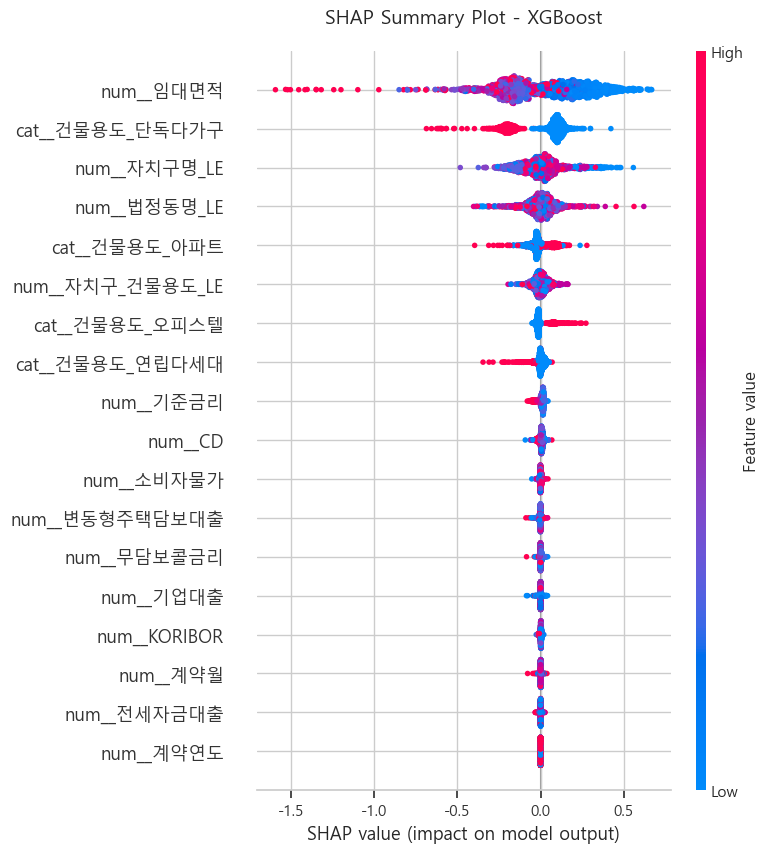

📊 Summary Plot 설명:
   - 각 점: 하나의 샘플
   - X축: SHAP 값 (양수 = 평당가 증가, 음수 = 평당가 감소)
   - 색상: 피처 값 (빨강 = 높음, 파랑 = 낮음)
   - Y축: 피처 중요도 순서 (위쪽이 더 중요)


In [18]:
# ===================================
# Summary Plot - Beeswarm (피처별 영향도)
# ===================================

plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values, 
    X_sample_trans, 
    feature_names=feature_names, 
    show=False
)
plt.title(f"SHAP Summary Plot - {best_model}", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

print("📊 Summary Plot 설명:")
print("   - 각 점: 하나의 샘플")
print("   - X축: SHAP 값 (양수 = 평당가 증가, 음수 = 평당가 감소)")
print("   - 색상: 피처 값 (빨강 = 높음, 파랑 = 낮음)")
print("   - Y축: 피처 중요도 순서 (위쪽이 더 중요)")


### SHAP Bar Plot - 평균 절대 중요도

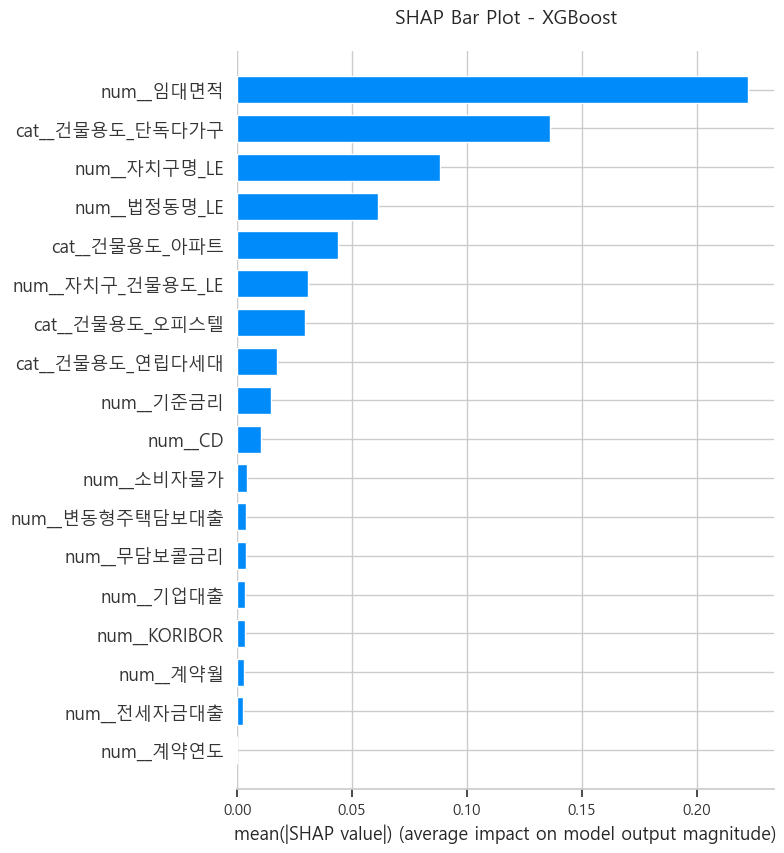

📊 Bar Plot 설명:
   - 평균 절대 SHAP 값으로 피처 중요도 순위 표시
   - 값이 클수록 모델 예측에 더 큰 영향


In [19]:
# ===================================
# Bar Plot - 평균 절대 SHAP 중요도
# ===================================

plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, 
    X_sample_trans, 
    feature_names=feature_names,
    plot_type="bar",
    show=False
)
plt.title(f"SHAP Bar Plot - {best_model}", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

print("📊 Bar Plot 설명:")
print("   - 평균 절대 SHAP 값으로 피처 중요도 순위 표시")
print("   - 값이 클수록 모델 예측에 더 큰 영향")
